# Member 3: ML strategy, modelling and comparison

**IT3091 | WE-AI-30 | Guided Data Track | Retail & E-commerce**

## 1. Objective and modelling scope

Group identified customers by historical purchasing behaviour using the promised
rule-based RFM baseline, K-Means, Ward hierarchical clustering and Gaussian Mixture.
This is unsupervised segmentation: there is no prediction target or purchase classifier.
Member 2 has already cleaned, engineered, transformed and scaled the input.
Member 4 owns future behavioural validation, final business names and recommendations.

All fitting uses the existing three scaled RFM columns. Transactions on or after
**2011-09-09 00:00:00** are reserved. No Member 1 EDA or Member 2 preprocessing is rerun.
The audit reads only customer/date metadata from the already cleaned historical file.

This notebook is generated from the adjacent percent-cell Python source. Run
`python members/member-3/notebooks/run_notebook.py` from the project root to regenerate
and execute it in a fresh kernel. See the Member 3 README for dependencies.

In [1]:
import os
# Fix numerical thread counts before importing numpy/sklearn in a fresh process.
for variable in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"]:
    os.environ[variable] = "1"

from pathlib import Path
import sys
import json
import platform
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from scipy.cluster.hierarchy import dendrogram
from sklearn.decomposition import PCA

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "data/processed/rfm_table.csv").exists() and (p / "members").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Run from the cloned repository or a directory inside it")
WORK = ROOT / "members/member-3"
sys.path.insert(0, str(WORK / "notebooks"))
from modelling_helpers import (
    FEATURES, RAW, SEEDS, COUNTS, fingerprint, audit_input, rfm_baseline,
    cluster_metrics, experiment, repeat_experiments, profiles, markdown_table,
)

DOCS, FIGURES, RESULTS = WORK / "docs", WORK / "figures", WORK / "results"
for folder in [DOCS, FIGURES, RESULTS]:
    folder.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

def save_figure(fig, name):
    fig.tight_layout()
    path = FIGURES / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight", metadata={"Software": "Member 3 modelling"})
    plt.close(fig)
    display(Image(filename=str(path)))

def save_table(frame, name):
    frame.to_csv(RESULTS / f"{name}.csv", index=False, float_format="%.12g")

## 2. Load model-ready RFM and verify the Member 2 handoff

The input is read unchanged. We check schema, IDs, missing/infinite values, raw domains,
log1p relationships, and the existing scaler's algebra to CSV precision (1e-7 absolute
tolerance). That algebra is an audit only; it never replaces model features or fits a scaler.
Population standard deviation (`ddof=0`) should be one; the sample standard deviation
is slightly larger. Repeated feature vectors are valid distinct customers and are retained.

The transaction date audit and Member 2's `< 2011-09-09` source filter support historical
provenance. Hashes bind this run to the exact input artifacts. The future raw file is not
read by the modelling workflow. Full-data EDA statistics are context, not modelling input.

In [2]:
RFM_PATH = ROOT / "data/processed/rfm_table.csv"
TRANSACTIONS_PATH = ROOT / "data/interim/cleaned_transactions.csv"
input_hashes = {p.relative_to(ROOT).as_posix(): fingerprint(p)
                for p in [RFM_PATH, TRANSACTIONS_PATH]}
rfm = pd.read_csv(RFM_PATH)
audit = audit_input(rfm, TRANSACTIONS_PATH)
(RESULTS / "input_audit.json").write_text(json.dumps(audit, indent=2) + "\n", encoding="utf-8")
input_summary = rfm.describe().T.reset_index(names="feature")
input_summary["dtype"] = input_summary.feature.map(rfm.dtypes.astype(str))
save_table(input_summary, "input_summary")
display(Markdown(f"**Handoff passed:** {audit['rows']:,} unique customer rows; "
                 f"no missing/infinite values or duplicate IDs. "
                 f"Latest historical transaction: {audit['date_max']}."))
display(input_summary)
display(pd.DataFrame({"mean": rfm[FEATURES].mean(),
                      "population_std": rfm[FEATURES].std(ddof=0),
                      "sample_std": rfm[FEATURES].std(ddof=1)}))
print("Input fingerprints:", json.dumps(input_hashes, indent=2))

**Handoff passed:** 3,362 unique customer rows; no missing/infinite values or duplicate IDs. Latest historical transaction: 2011-09-08 19:58:00.

,feature,count,mean,std,min,25%,50%,75%,max,dtype
0,CustomerID,3362.0,1.527663e+04,1726.153144,12346.000000,13786.250000,15234.500000,16766.750000,18287.000000,int64
1,Recency,3362.0,9.386734e+01,79.615202,0.000000,25.000000,73.000000,150.000000,281.000000,int64
2,Frequency,3362.0,3.514277e+00,5.753796,1.000000,1.000000,2.000000,4.000000,131.000000,int64
3,Monetary,3362.0,1.594714e+03,6110.006790,2.900000,260.657500,555.015000,1363.262500,177729.620000,float64
4,Log_Frequency,3362.0,1.237508e+00,0.626650,0.693147,0.693147,1.098612,1.609438,4.882802,float64
5,Log_Monetary,3362.0,6.403739e+00,1.222237,1.360977,5.567036,6.320795,7.218369,12.088024,float64
6,Recency_scaled,3362.0,5.948844e-12,1.000149,-1.179188,-0.865131,-0.262141,0.705154,2.350814,float64
7,Frequency_scaled,3362.0,-9.547888e-11,1.000149,-0.868813,-0.868813,-0.221681,0.593609,5.817979,float64
8,Monetary_scaled,3362.0,6.246275e-12,1.000149,-4.126459,-0.684668,-0.067873,0.666606,4.651412,float64


,mean,population_std,sample_std
Recency_scaled,5.948844e-12,1.0,1.000149
Frequency_scaled,-9.547888e-11,1.0,1.000149
Monetary_scaled,6.246275e-12,1.0,1.000149


Input fingerprints: {
  "data/processed/rfm_table.csv": "6bf62e981a1e91770908de3b104b67b8e1c0b726926967b19be7a76d0eaf45e2",
  "data/interim/cleaned_transactions.csv": "ec0bf1bd218cd8c93a27620fcbe093498718f65d8d88b761c75e5c162b3c3185"
}


## 3. Define the feature matrix

Only `Recency_scaled`, `Frequency_scaled`, `Monetary_scaled` enter the models and
distance metrics. The last two represent scaled **log1p** Frequency and Monetary.
CustomerID is only a join key. Raw RFM remains available for profiles in days, invoice
counts and GBP. Standardization equalizes marginal variance but does not remove the
Frequency/Monetary correlation or guarantee normally distributed features.

In [3]:
X = rfm[FEATURES].to_numpy(dtype=float, copy=True)
assert X.shape == (len(rfm), 3)
X.setflags(write=False)
print("Feature matrix:", X.shape, FEATURES)
print("Historical Spearman(F, M):", audit["frequency_monetary_spearman"])

Feature matrix: (3362, 3) ['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']
Historical Spearman(F, M): 0.7841763347840829


## 4. Rule-based RFM baseline

Rank each variable worst-to-best (Recency descending, Frequency/Monetary ascending),
using the average rank for ties. Let `p = (average_rank - 0.5) / n`, then
`score = floor(5*p) + 1`, clipped to 1..5. This is an empirical midrank quintile rule:
ties never split by row order or CustomerID. Large ties can leave some scores unused;
we do not force five equal-sized bins or discard duplicate quantile edges.

Combine scores with equal weights: `total = R + F + M` (3..15).
Fixed neutral groups are 0: total 3..6, 1: 7..9, 2: 10..12, 3: 13..15.
Equivalently, mean scores are <=2, >2..3, >3..4, and >4. These thresholds are fixed
before inspecting ML results. They provide four explainable groups without 125 tiny
RFM combinations. Compensation between dimensions and correlated F/M are limitations.

Silhouette, Davies-Bouldin and Calinski-Harabasz evaluate these rule-based labels
on the exact same scaled matrix. They do not turn the baseline into an ML model.

In [4]:
baseline = rfm_baseline(rfm)
baseline_row = {"method": "RFM_Baseline", "k": baseline.RFM_Baseline_Group.nunique(),
                "seed": np.nan, **cluster_metrics(X, baseline.RFM_Baseline_Group)}
baseline_profiles = profiles(rfm, baseline.RFM_Baseline_Group, "RFM_Baseline_Group")
score_ranges = pd.concat([
    rfm.assign(score=baseline[f"{short}_Score"]).groupby("score")[raw]
       .agg(["min", "max", "count"]).reset_index().assign(feature=raw)
    for raw, short in zip(RAW, ["R", "F", "M"])
], ignore_index=True)[["feature", "score", "min", "max", "count"]]
save_table(score_ranges, "baseline_score_ranges")
display(score_ranges)
display(baseline_profiles)

,feature,score,min,max,count
0,Recency,1,170.00,281.00,665
1,Recency,2,98.00,169.00,673
2,Recency,3,51.00,97.00,680
3,Recency,4,20.00,50.00,670
4,Recency,5,0.00,18.00,674
5,Frequency,2,1.00,1.00,1366
6,Frequency,3,2.00,2.00,668
7,Frequency,4,3.00,4.00,654
8,Frequency,5,5.00,131.00,674
9,Monetary,1,2.90,213.55,672


,solution,cluster,customers,percentage,median_recency,median_frequency,median_monetary,mean_recency,mean_frequency,mean_monetary
0,RFM_Baseline_Group,0,935,27.810827,182.0,1.0,190.55,182.447059,1.054545,220.710096
1,RFM_Baseline_Group,1,905,26.918501,88.0,2.0,409.63,95.150276,1.658564,606.159878
2,RFM_Baseline_Group,2,803,23.884593,46.0,3.0,905.60,55.344956,3.127024,1228.494785
3,RFM_Baseline_Group,3,719,21.386080,15.0,7.0,2433.22,20.084840,9.481224,5034.781919


## 5. K-Means experiments

Search k=2..8 with seed 42, k-means++ initialization, 20 restarts, Lloyd's algorithm,
500 maximum iterations and tolerance 1e-4. Explicit restarts avoid relying on changing
library defaults. Retain inertia, full-data silhouette, Davies-Bouldin (lower is better),
Calinski-Harabasz (higher is better) and all cluster sizes. Full-data silhouette is feasible
for this cohort; no changing random metric sample obscures comparisons.

An elbow alone cannot establish k. We examine separation, stability, raw profiles and
group sizes together. No minimum group threshold is imposed as a hidden exclusion rule.

,method,k,seed,groups,silhouette,davies_bouldin,calinski_harabasz,smallest_cluster,largest_cluster,smallest_pct,sizes,inertia,iterations
0,KMeans,2,42,2,0.411376,0.904482,3136.787746,1395,1967,41.493159,"{""0"": 1967, ""1"": 1395}",5216.281291,14
1,KMeans,3,42,3,0.372795,0.915768,3135.748182,866,1520,25.758477,"{""0"": 866, ""1"": 976, ""2"": 1520}",3517.885446,10
2,KMeans,4,42,4,0.346009,0.949829,3039.661351,470,1112,13.979774,"{""0"": 1112, ""1"": 893, ""2"": 470, ""3"": 887}",2714.501185,7
3,KMeans,5,42,5,0.323936,0.994066,2768.890078,184,965,5.472933,"{""0"": 865, ""1"": 965, ""2"": 184, ""3"": 726, ""4"": ...",2346.004646,10
4,KMeans,6,42,6,0.314838,0.969637,2662.284604,190,758,5.651398,"{""0"": 190, ""1"": 488, ""2"": 635, ""3"": 758, ""4"": ...",2030.830239,12
5,KMeans,7,42,7,0.300980,0.980874,2528.254150,184,725,5.472933,"{""0"": 600, ""1"": 563, ""2"": 377, ""3"": 725, ""4"": ...",1826.690361,57
6,KMeans,8,42,8,0.281249,1.049436,2409.545766,134,617,3.985723,"{""0"": 371, ""1"": 603, ""2"": 367, ""3"": 134, ""4"": ...",1672.970493,25


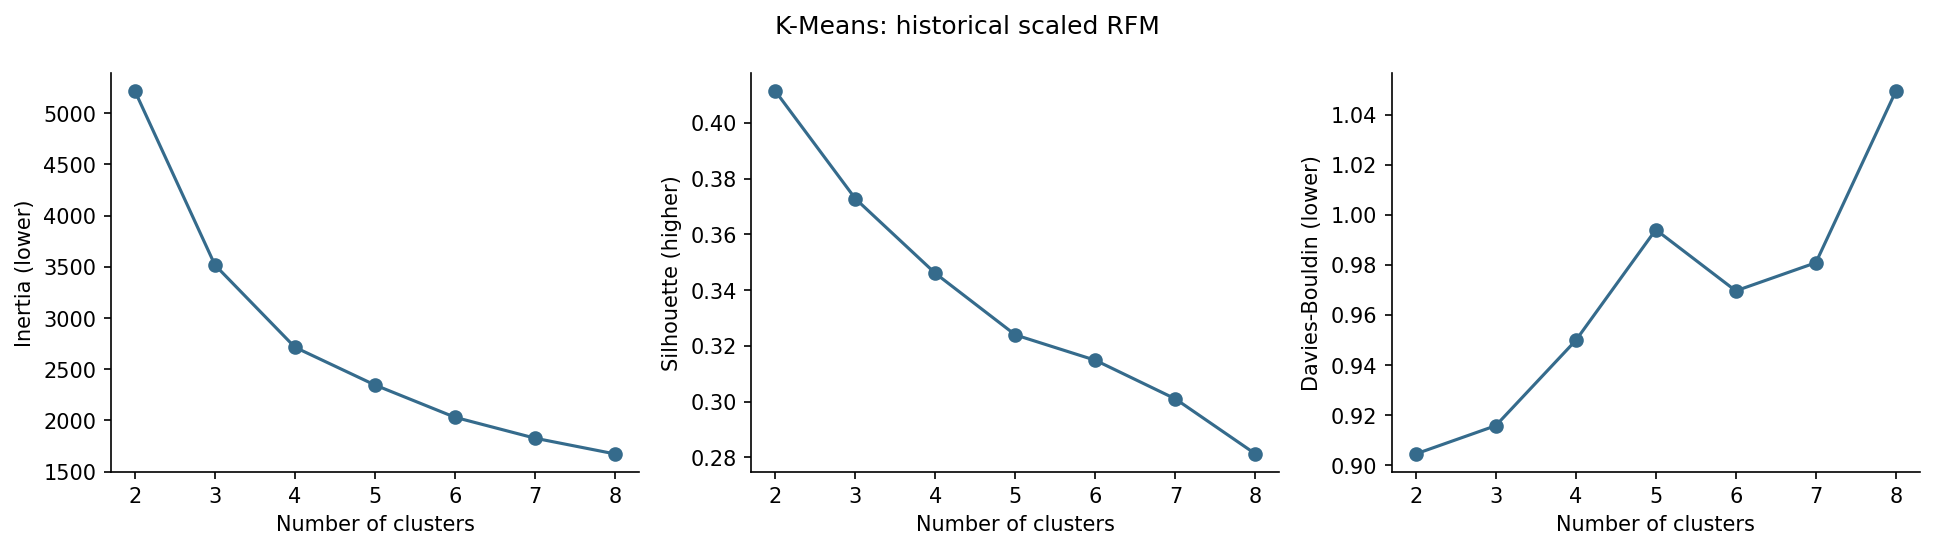

In [5]:
primary = {}
for k in COUNTS:
    primary[("KMeans", k)] = experiment("KMeans", k, X)
kmeans_results = pd.DataFrame([primary[("KMeans", k)][0] for k in COUNTS])
display(kmeans_results)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.7))
for ax, metric, title in zip(axes, ["inertia", "silhouette", "davies_bouldin"],
                            ["Inertia (lower)", "Silhouette (higher)", "Davies-Bouldin (lower)"]):
    ax.plot(kmeans_results.k, kmeans_results[metric], marker="o", color="#356b8c")
    ax.set(xlabel="Number of clusters", ylabel=title, xticks=list(COUNTS))
fig.suptitle("K-Means: historical scaled RFM")
save_figure(fig, "kmeans_search")

## 6. Hierarchical / Agglomerative experiments

Ward linkage minimizes increases in within-group squared Euclidean dispersion.
Search k=2..8 on all customers and the same three features. No random initialization
is involved for a fixed dataset/order, distance and linkage; seed repetitions are not
meaningful. Determinism does not prove robustness to changed samples or time windows.

The dendrogram is built from the fitted sklearn model's actual merge tree, using SciPy
only to display the final 20 merged branches. Parentheses indicate branch populations,
not individual customer names. There is no dendrogram-only sampling or different fit.

,method,k,seed,groups,silhouette,davies_bouldin,calinski_harabasz,smallest_cluster,largest_cluster,smallest_pct,sizes
0,Hierarchical,2,NaN,2,0.392839,0.946754,2896.425693,1645,1717,48.929209,"{""0"": 1717, ""1"": 1645}"
1,Hierarchical,3,NaN,3,0.338899,0.931723,2565.992992,380,1645,11.302796,"{""0"": 1645, ""1"": 1337, ""2"": 380}"
2,Hierarchical,4,NaN,4,0.314724,0.943247,2676.904969,380,1337,11.302796,"{""0"": 1337, ""1"": 939, ""2"": 380, ""3"": 706}"
3,Hierarchical,5,NaN,5,0.262130,1.137736,2432.127404,380,939,11.302796,"{""0"": 939, ""1"": 628, ""2"": 380, ""3"": 706, ""4"": ..."
4,Hierarchical,6,NaN,6,0.257721,1.168310,2305.938538,251,709,7.465794,"{""0"": 380, ""1"": 628, ""2"": 688, ""3"": 706, ""4"": ..."
5,Hierarchical,7,NaN,7,0.259341,1.080557,2137.533100,23,709,0.684117,"{""0"": 688, ""1"": 628, ""2"": 357, ""3"": 706, ""4"": ..."
6,Hierarchical,8,NaN,8,0.238504,1.077696,2002.636338,23,709,0.684117,"{""0"": 628, ""1"": 709, ""2"": 357, ""3"": 706, ""4"": ..."


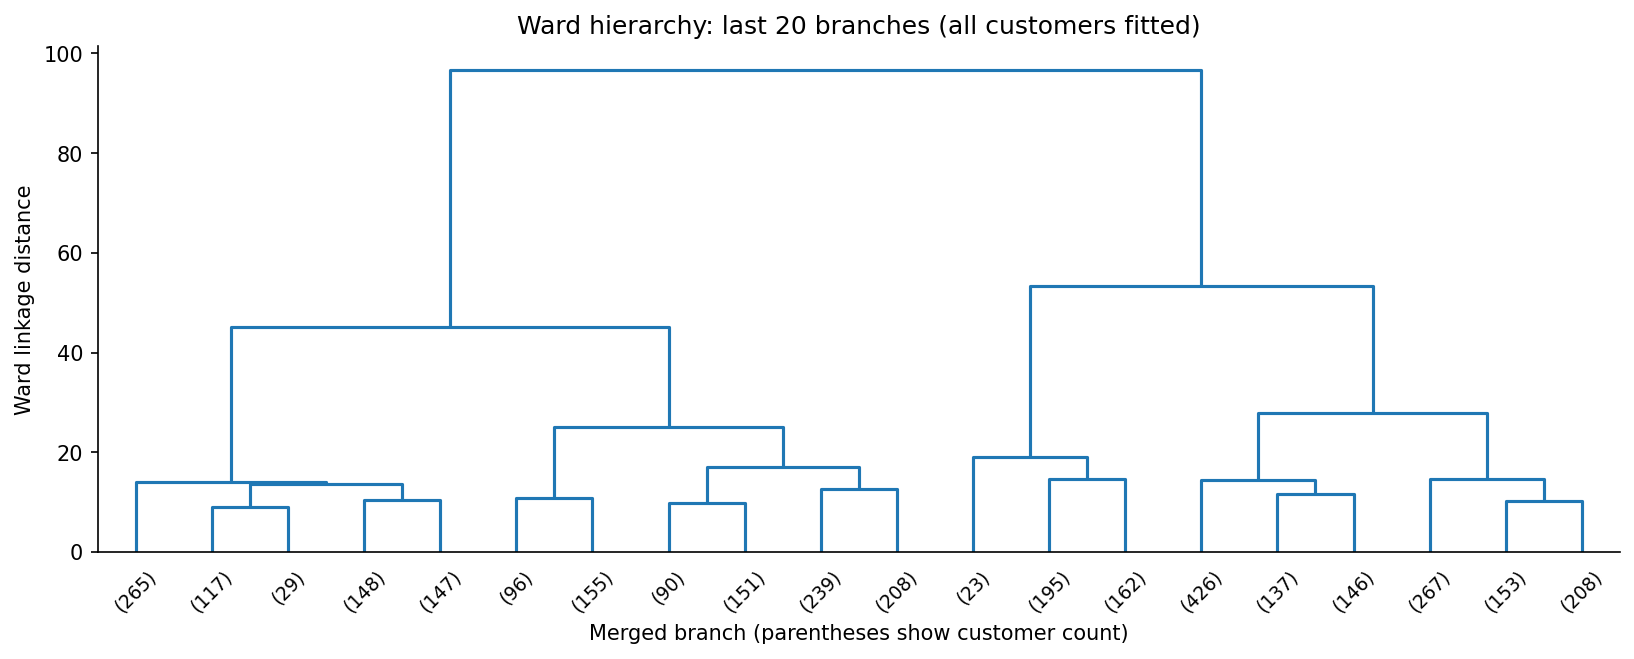

In [6]:
for k in COUNTS:
    primary[("Hierarchical", k)] = experiment("Hierarchical", k, X)
hierarchical_results = pd.DataFrame([primary[("Hierarchical", k)][0] for k in COUNTS])
display(hierarchical_results)
tree = primary[("Hierarchical", 2)][2]
counts = np.zeros(len(tree.children_))
for i, children in enumerate(tree.children_):
    counts[i] = sum(1 if child < len(X) else counts[child - len(X)] for child in children)
linkage_matrix = np.column_stack([tree.children_, tree.distances_, counts]).astype(float)
fig, ax = plt.subplots(figsize=(11, 4.5))
dendrogram(linkage_matrix, truncate_mode="lastp", p=20, show_leaf_counts=True,
           leaf_rotation=45, leaf_font_size=9, color_threshold=0, ax=ax)
ax.set(title="Ward hierarchy: last 20 branches (all customers fitted)",
       xlabel="Merged branch (parentheses show customer count)", ylabel="Ward linkage distance")
save_figure(fig, "ward_dendrogram")

## 7. Gaussian Mixture experiments

Search 2..8 full-covariance Gaussian components with seed 42, 10 initializations,
500 maximum EM iterations, tolerance 1e-3 and diagonal regularization 1e-6.
Full covariance can model correlated, elliptical groups; posterior probabilities
describe overlap. Labels are maximum-posterior assignments on the same three features.

AIC and BIC (lower preferred within these GMM fits) assess penalized in-sample density
fit. They are not interchangeable with geometric separation or future validation.
We retain covariance minimum eigenvalues to detect components compressed against the
regularization floor, particularly because Frequency has many ties. We report maximum
posterior <0.70 as a descriptive ambiguity threshold, not a ground-truth error rate.
Convergence warnings fail the run rather than disappearing silently.

,method,k,seed,groups,silhouette,davies_bouldin,calinski_harabasz,smallest_cluster,largest_cluster,smallest_pct,sizes,aic,bic,iterations,converged,mean_confidence,low_confidence_count,low_confidence_pct,min_covariance_eigenvalue
0,GMM,2,42,2,0.380231,0.972373,2723.707864,1650,1712,49.077930,"{""0"": 1650, ""1"": 1712}",21957.124270,22073.409805,6,True,0.887989,637,18.947055,1.042343e-01
1,GMM,3,42,3,0.210485,1.396105,1758.071911,992,1366,29.506246,"{""0"": 992, ""1"": 1366, ""2"": 1004}",6139.125266,6316.613714,9,True,0.921541,486,14.455681,1.000000e-06
2,GMM,4,42,4,0.134705,1.682617,1389.062085,570,1366,16.954194,"{""0"": 758, ""1"": 668, ""2"": 1366, ""3"": 570}",-1003.255654,-764.564293,14,True,0.945982,297,8.834027,1.000000e-06
3,GMM,5,42,5,0.097349,2.005191,1181.849367,396,1366,11.778703,"{""0"": 668, ""1"": 524, ""2"": 408, ""3"": 396, ""4"": ...",-5132.696357,-4832.802083,27,True,0.959935,231,6.870910,1.000000e-06
4,GMM,6,42,6,0.102115,1.895161,1026.944531,181,1366,5.383700,"{""0"": 447, ""1"": 1366, ""2"": 408, ""3"": 668, ""4"":...",-5341.833462,-4980.736275,23,True,0.945069,288,8.566330,1.000000e-06
5,GMM,7,42,7,0.085550,1.745303,1083.745727,165,1201,4.907793,"{""0"": 165, ""1"": 460, ""2"": 1201, ""3"": 260, ""4"":...",-5671.398679,-5249.098578,30,True,0.937728,296,8.804283,1.000000e-06
6,GMM,8,42,8,0.159702,1.954909,1265.385866,95,772,2.825699,"{""0"": 772, ""1"": 95, ""2"": 213, ""3"": 594, ""4"": 4...",-7830.196565,-7346.693551,21,True,0.919211,406,12.076145,1.000000e-06


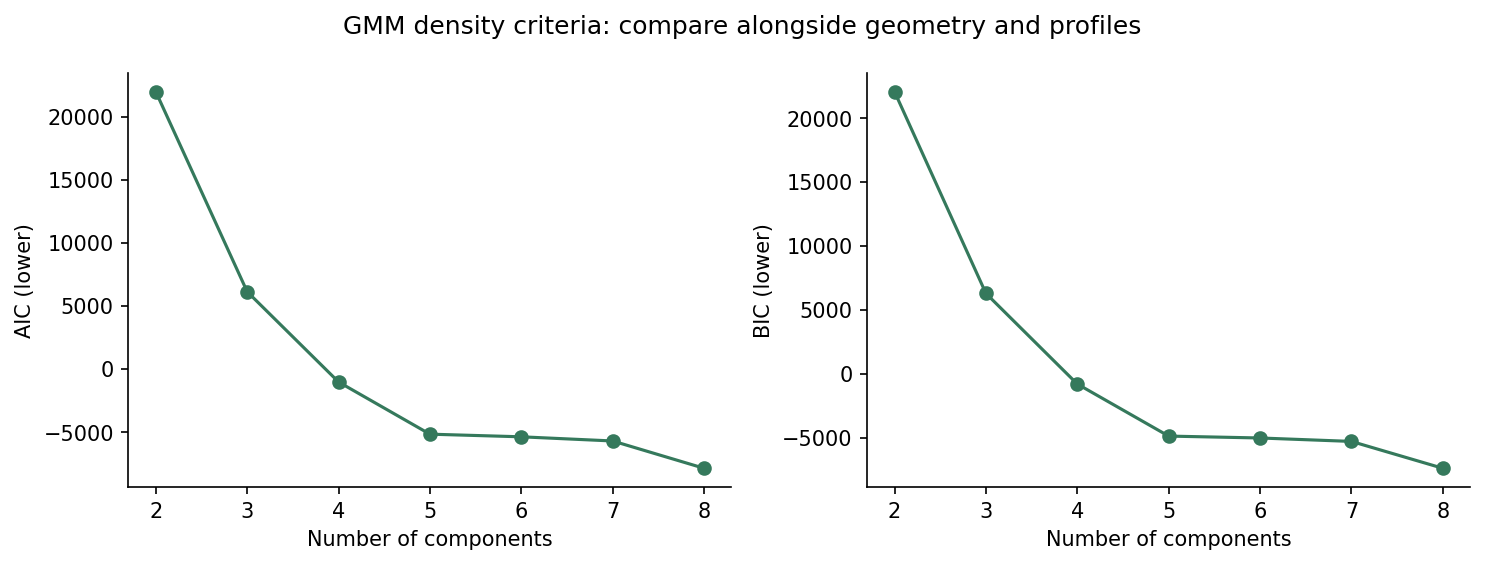

In [7]:
for k in COUNTS:
    primary[("GMM", k)] = experiment("GMM", k, X)
gmm_results = pd.DataFrame([primary[("GMM", k)][0] for k in COUNTS])
display(gmm_results)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, metric in zip(axes, ["aic", "bic"]):
    ax.plot(gmm_results.k, gmm_results[metric], marker="o", color="#35795c")
    ax.set(xlabel="Number of components", ylabel=metric.upper() + " (lower)", xticks=list(COUNTS))
fig.suptitle("GMM density criteria: compare alongside geometry and profiles")
save_figure(fig, "gmm_information_criteria")

## 8. Stability analysis

Repeat every stochastic configuration at seeds 42, 7, 21, 99, 123, keeping all other
parameters fixed. This assesses the actual multistart procedure, not single-start runs.
Report all ten pairwise Adjusted Rand Index (ARI) values per configuration. ARI is
invariant to label permutation: 1 means the same partition; near 0 means chance-level
agreement under its adjustment. Numeric cluster IDs need not match between runs.

Also retain per-seed metrics and objective values. Reusing the primary seed-42 run
gives five distinct seeds, not six trials. These are initialization checks on the same
customers, not confidence intervals, resampling tests or three-month temporal validation.

In [8]:
seed_runs, stability_pairs, stability_summary = repeat_experiments(X, primary)
save_table(seed_runs, "stability_runs")
save_table(stability_pairs, "stability_pairs")
save_table(stability_summary, "stability_summary")
experiments = pd.DataFrame([baseline_row] + [result[0] for result in primary.values()])
experiments = experiments.merge(stability_summary, on=["method", "k"], how="left")
save_table(experiments, "experiments")
display(stability_summary)
print("Primary fits and stability complete; results saved under members/member-3/results")

Stability complete: KMeans k=2


Stability complete: KMeans k=3


Stability complete: KMeans k=4


Stability complete: KMeans k=5


Stability complete: KMeans k=6


...

Stability complete: GMM k=6


Stability complete: GMM k=7


Stability complete: GMM k=8


,method,k,ari_mean,ari_min,ari_max,ari_std,pairs
0,GMM,2,1.000000,1.000000,1.000000,0.000000,10
1,GMM,3,0.999529,0.999214,1.000000,0.000406,10
2,GMM,4,0.998732,0.997695,1.000000,0.001009,10
3,GMM,5,0.960712,0.917268,1.000000,0.031868,10
4,GMM,6,0.995185,0.990256,0.998356,0.002840,10
5,GMM,7,0.996216,0.992040,1.000000,0.002488,10
6,GMM,8,0.786381,0.651679,0.997813,0.124954,10
7,KMeans,2,1.000000,1.000000,1.000000,0.000000,10
8,KMeans,3,0.998894,0.998157,1.000000,0.000952,10
9,KMeans,4,0.992698,0.983390,0.999098,0.005192,10


Primary fits and stability complete; results saved under members/member-3/results


## 9. Cross-method comparison and candidate solutions

The executed search supports **K-Means k=2 as the leading technical candidate**:
it leads the primary search on silhouette, Davies-Bouldin and Calinski-Harabasz,
with stable and substantial groups. Retain **K-Means k=3** as a finer alternative;
raw profiles below must show what the additional group contributes. Ward k=2 and
GMM k=2 are cross-method comparators. None is a final business winner.

Retain GMM k=8 explicitly as a **density-criterion diagnostic**, because AIC/BIC favour
it within the tested range. Its lower geometric separation, covariance-floor behaviour
and initialization sensitivity prevent declaring it the best customer segmentation.
The endpoint optimum does not prove that eight components is a global density optimum.

The table includes strength and limitation notes, with deterministic stability marked
not applicable. See the generated comparison document for all primary configurations,
the complete stability summary, and the seven decision dimensions used in the discussion.

In [9]:
# These choices were made after reviewing the complete executed 2..8 search.
# Guards below prevent stale recommendations if input or library behaviour changes.
leading = experiments[(experiments.method == "KMeans") & (experiments.k == 2)].iloc[0]
assert np.isclose(leading.silhouette, experiments.silhouette.max())
assert np.isclose(leading.davies_bouldin, experiments.davies_bouldin.min())
assert np.isclose(leading.calinski_harabasz, experiments.calinski_harabasz.max())
assert int(gmm_results.loc[gmm_results.bic.idxmin(), "k"]) == 8
assert int(gmm_results.loc[gmm_results.aic.idxmin(), "k"]) == 8
selected = [("KMeans", 2), ("KMeans", 3), ("Hierarchical", 2), ("GMM", 2), ("GMM", 8)]
names = {(method, k): f"{method}_k{k}" for method, k in selected}
names[("GMM", 8)] = "GMM_k8_Diagnostic"
candidate_labels = {"RFM_Baseline_Group": baseline.RFM_Baseline_Group.to_numpy()}
candidate_labels.update({names[key]: primary[key][1] for key in selected})
notes = {
    "RFM_Baseline": ("Fixed midrank score bands", "Deterministic; seed ARI N/A",
                     "Transparent scores", "Simple operational reference", "Compensates across R/F/M; ties unbalance bins"),
    "KMeans": ("k-means++; n_init=20; Lloyd", "Five-seed ARI below",
               "Centroids and raw profiles", "Compact groups; straightforward assignment", "Spherical bias; residual extremes"),
    "Hierarchical": ("Ward; Euclidean", "Deterministic; seed ARI N/A",
                     "Merge tree and raw profiles", "Nested partition; no random starts", "Greedy merges; quadratic scaling"),
    "GMM": ("Full covariance; n_init=10", "Five-seed ARI below",
            "Posterior probabilities and profiles", "Allows elliptical overlap", "Density fit can follow discrete Frequency; local optima"),
}
comparison = experiments.loc[
    [(row.method, row.k) in selected or row.method == "RFM_Baseline"
     for row in experiments.itertuples()]
].copy()
for i, field in enumerate(["configuration", "stability_note", "interpretability", "strengths", "limitations"]):
    comparison[field] = comparison.method.map(lambda method: notes[method][i])
comparison["role"] = ["Rule-based reference", "Leading technical", "Finer secondary",
                      "Cross-method comparator", "Cross-method comparator", "Density diagnostic only"]
save_table(comparison, "candidate_comparison")
display(comparison[["method", "k", "silhouette", "davies_bouldin", "calinski_harabasz",
                    "smallest_cluster", "largest_cluster", "ari_mean", "ari_min", "role"]])

,method,k,silhouette,davies_bouldin,calinski_harabasz,smallest_cluster,largest_cluster,ari_mean,ari_min,role
0,RFM_Baseline,4,0.221962,1.417436,2097.518030,719,935,NaN,NaN,Rule-based reference
1,KMeans,2,0.411376,0.904482,3136.787746,1395,1967,1.000000,1.000000,Leading technical
2,KMeans,3,0.372795,0.915768,3135.748182,866,1520,0.998894,0.998157,Finer secondary
8,Hierarchical,2,0.392839,0.946754,2896.425693,1645,1717,NaN,NaN,Cross-method comparator
15,GMM,2,0.380231,0.972373,2723.707864,1650,1712,1.000000,1.000000,Cross-method comparator
21,GMM,8,0.159702,1.954909,1265.385866,95,772,0.786381,0.651679,Density diagnostic only


## 10. Raw RFM profiles and GMM diagnostics

Every searched configuration is profiled in original units; shortlisted profiles are
displayed here. Counts and percentages describe customers, not transaction rows.
Means accompany medians to show skew. All cluster numbers are neutral and local to
their configuration. Member 4 will assign final segment names after behavioural validation.

The GMM diagnostic table records each component's number and range of observed raw
Frequency values and minimum covariance eigenvalue. A high posterior can reflect a
narrow component fitted to a repeated discrete value; it is not proof of a real customer type.

In [10]:
all_profiles = pd.concat([baseline_profiles] + [
    profiles(rfm, result[1], names.get(key, f"{key[0]}_k{key[1]}"))
    for key, result in primary.items()
], ignore_index=True)
save_table(all_profiles, "cluster_profiles")
candidate_profiles = all_profiles[all_profiles.solution.isin(candidate_labels)].copy()
display(candidate_profiles)
gmm_diagnostics = []
for k in COUNTS:
    _, labels, model = primary[("GMM", k)]
    for cluster in range(k):
        frequency = rfm.loc[labels == cluster, "Frequency"]
        gmm_diagnostics.append({"k": k, "cluster": cluster, "customers": len(frequency),
                                "frequency_unique": frequency.nunique(),
                                "frequency_min": frequency.min(), "frequency_max": frequency.max(),
                                "min_covariance_eigenvalue": np.linalg.eigvalsh(model.covariances_[cluster]).min()})
gmm_diagnostics = pd.DataFrame(gmm_diagnostics)
save_table(gmm_diagnostics, "gmm_component_diagnostics")
display(gmm_diagnostics[gmm_diagnostics.k.isin([2, 8])])

,solution,cluster,customers,percentage,median_recency,median_frequency,median_monetary,mean_recency,mean_frequency,mean_monetary
0,RFM_Baseline_Group,0,935,27.810827,182.0,1.0,190.550,182.447059,1.054545,220.710096
1,RFM_Baseline_Group,1,905,26.918501,88.0,2.0,409.630,95.150276,1.658564,606.159878
2,RFM_Baseline_Group,2,803,23.884593,46.0,3.0,905.600,55.344956,3.127024,1228.494785
3,RFM_Baseline_Group,3,719,21.386080,15.0,7.0,2433.220,20.084840,9.481224,5034.781919
4,KMeans_k2,0,1967,58.506841,125.0,1.0,304.100,133.928826,1.387392,385.484936
5,KMeans_k2,1,1395,41.493159,27.0,4.0,1561.060,37.379211,6.513262,3299.770087
6,KMeans_k3,0,866,25.758477,22.0,6.0,2284.955,33.303695,8.748268,4720.232390
7,KMeans_k3,1,976,29.030339,192.0,1.0,246.275,198.566598,1.238730,340.626680
8,KMeans_k3,2,1520,45.211184,58.0,2.0,498.480,61.144737,1.993421,619.246876
39,Hierarchical_k2,0,1717,51.070791,32.0,4.0,1228.190,41.120559,5.625510,2780.913024


,k,cluster,customers,frequency_unique,frequency_min,frequency_max,min_covariance_eigenvalue
0,2,0,1650,46,1,131,1.673584e-01
1,2,1,1712,6,1,6,1.042343e-01
27,8,0,772,1,1,1,1.000000e-06
28,8,1,95,7,5,34,8.974981e-02
29,8,2,213,41,5,131,7.179991e-03
30,8,3,594,1,1,1,1.000000e-06
31,8,4,408,1,3,3,1.000000e-06
32,8,5,366,14,5,24,4.328511e-02
33,8,6,668,1,2,2,1.000000e-06
34,8,7,246,1,4,4,1.000000e-06


## 11. Visualise candidate geometry and group sizes

PCA is fitted only to show the three scaled features in two dimensions. Every model
and metric above used all three scaled RFM features. Axis labels report explained
variance. Colour/cluster number is local to each panel; matching colours across methods
do not imply matching customer sets. Size charts include the rule baseline and GMM
density diagnostic so those alternatives remain visible.

PC1: **73.12%**, PC2: **19.86%**; combined **92.98%** of variance (visualisation only).

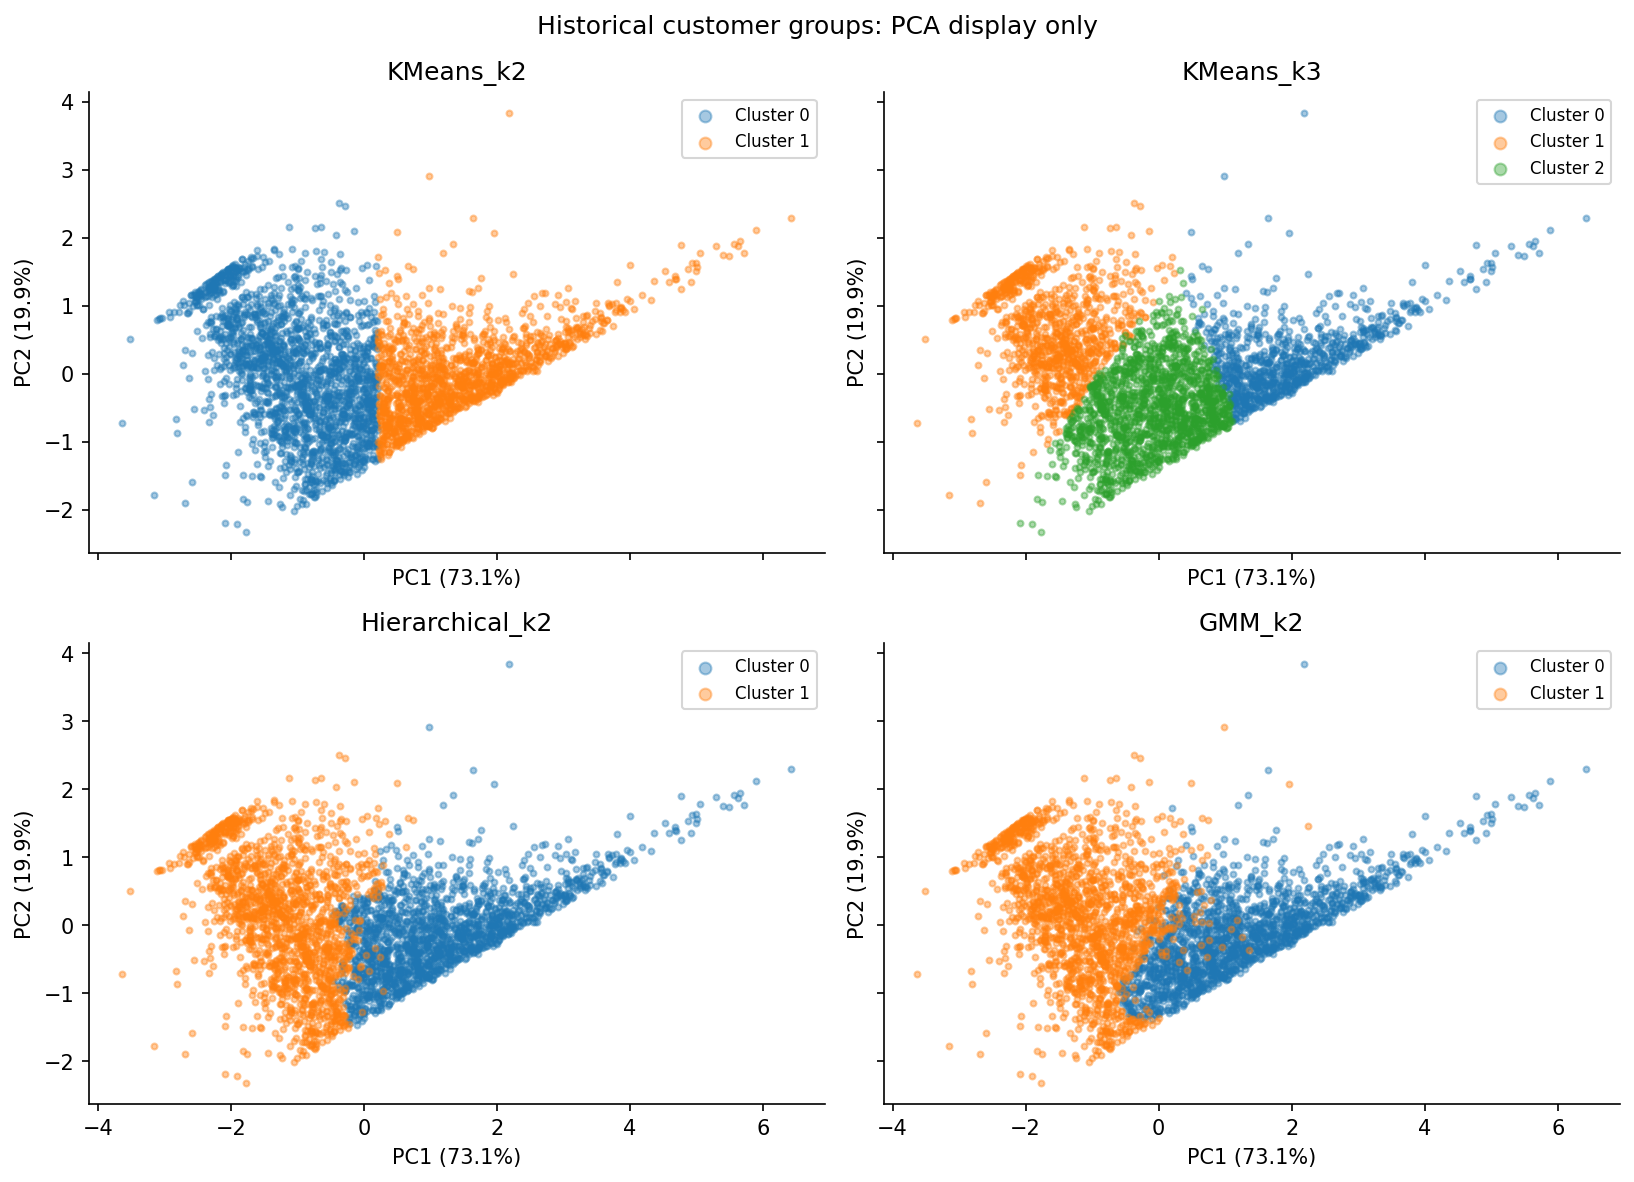

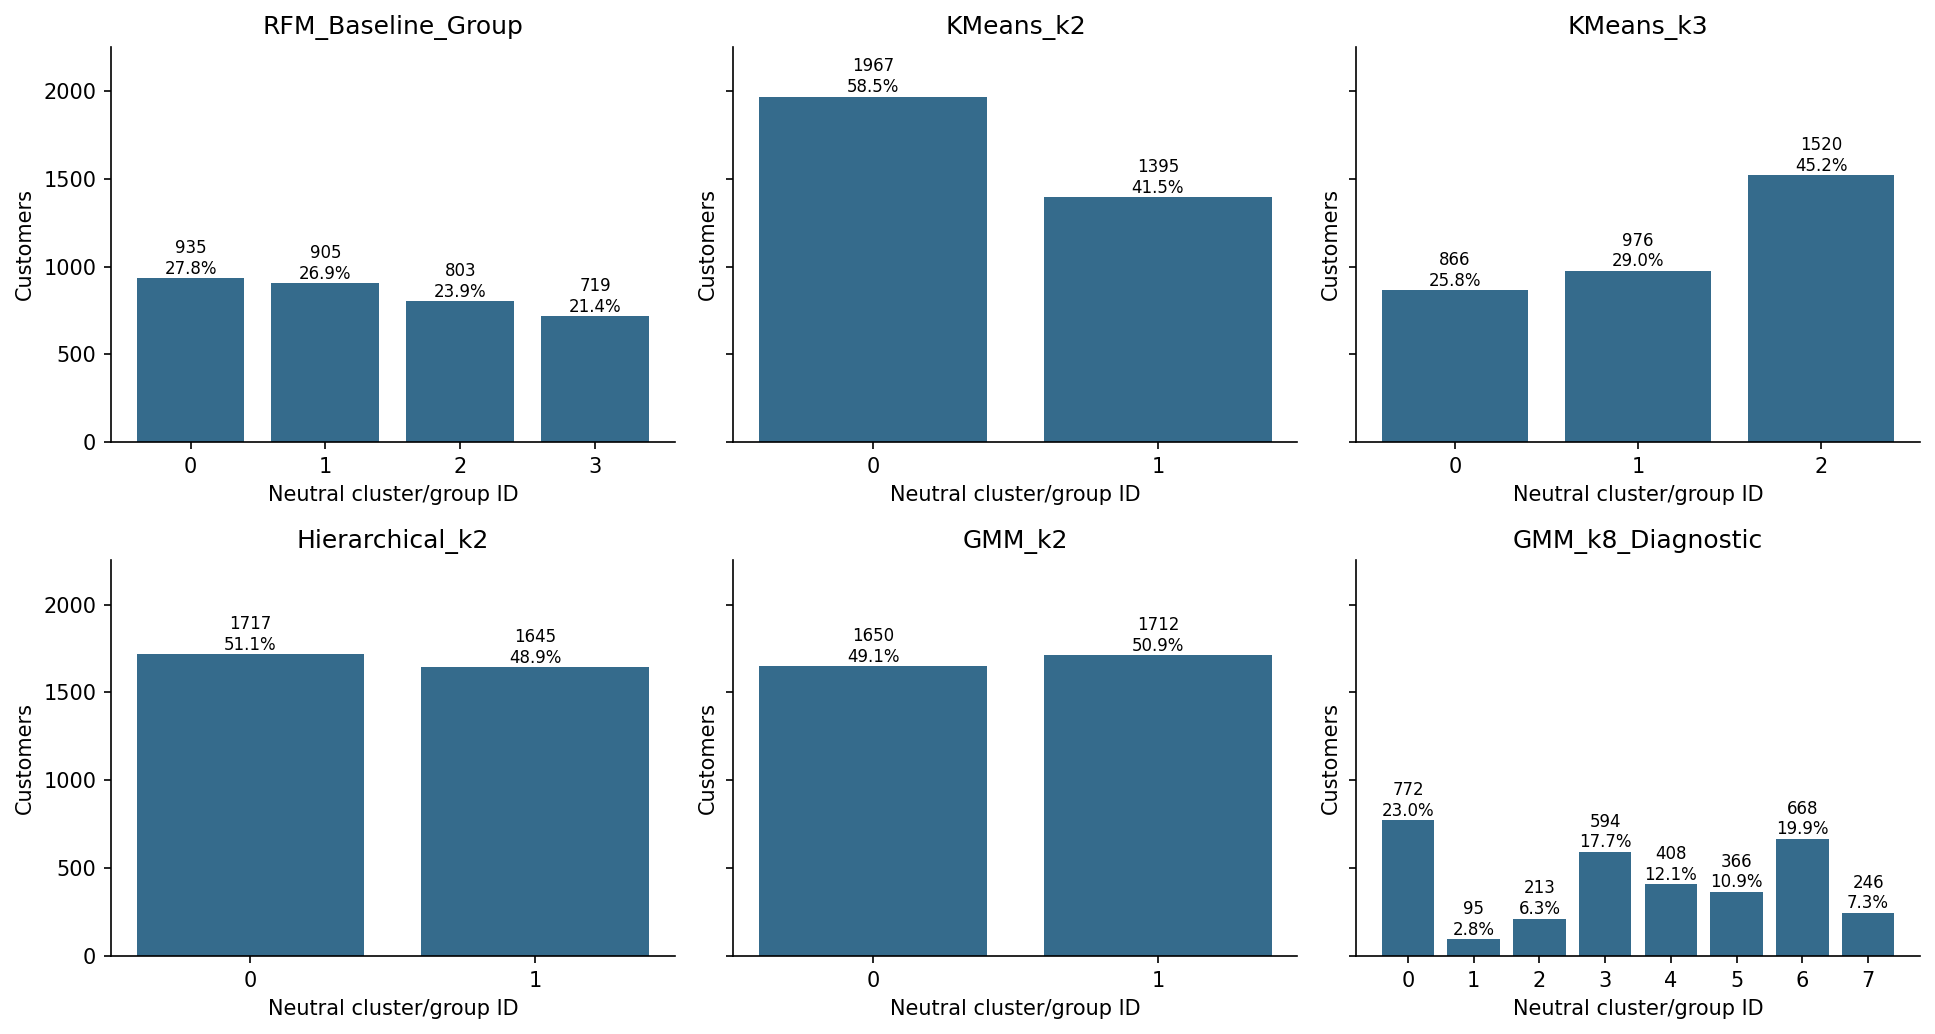

In [11]:
pca = PCA(n_components=2, svd_solver="full")
coordinates = pca.fit_transform(X)
pca_variance = pca.explained_variance_ratio_
display(Markdown(f"PC1: **{100*pca_variance[0]:.2f}%**, PC2: **{100*pca_variance[1]:.2f}%**; "
                 f"combined **{100*pca_variance.sum():.2f}%** of variance (visualisation only)."))
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, name in zip(axes.flat, ["KMeans_k2", "KMeans_k3", "Hierarchical_k2", "GMM_k2"]):
    labels = candidate_labels[name]
    for cluster in np.unique(labels):
        points = coordinates[labels == cluster]
        ax.scatter(points[:, 0], points[:, 1], s=8, alpha=.4,
                   color=plt.get_cmap("tab10")(int(cluster)), label=f"Cluster {cluster}", rasterized=True)
    ax.set(title=name, xlabel=f"PC1 ({100*pca_variance[0]:.1f}%)",
           ylabel=f"PC2 ({100*pca_variance[1]:.1f}%)")
    ax.legend(markerscale=2, fontsize=8)
fig.suptitle("Historical customer groups: PCA display only")
save_figure(fig, "candidate_pca")
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
for ax, (name, labels) in zip(axes.flat, candidate_labels.items()):
    sizes = pd.Series(labels).value_counts().sort_index()
    ax.bar(sizes.index, sizes, color="#356b8c")
    ax.set(title=name, xlabel="Neutral cluster/group ID", ylabel="Customers",
           xticks=list(sizes.index), ylim=(0, len(rfm)*.67))
    for cluster, size in sizes.items():
        ax.text(cluster, size+25, f"{size}\n{100*size/len(rfm):.1f}%", ha="center", fontsize=8)
save_figure(fig, "candidate_sizes")

## 12. Export frozen historical assignments

One row per original CustomerID, retaining raw RFM and clearly named candidate columns.
GMM k=8 is explicitly marked diagnostic. Posterior maxima for GMM k=2 and k=8 support
ambiguity analysis, not purchase-probability prediction. No ambiguous generic `Cluster`
column or final business name is exported. The original RFM file is never written.

In [12]:
assignments = rfm[["CustomerID", *RAW]].copy()
for name, labels in candidate_labels.items():
    assignments[name] = labels
for k in [2, 8]:
    name = "GMM_k2_MaxPosterior" if k == 2 else "GMM_k8_Diagnostic_MaxPosterior"
    assignments[name] = primary[("GMM", k)][2].predict_proba(X).max(axis=1)
OUTPUT = ROOT / "data/processed/cluster_assignments.csv"
assignments.to_csv(OUTPUT, index=False)
reloaded = pd.read_csv(OUTPUT)
pd.testing.assert_frame_equal(reloaded[["CustomerID", *RAW]], rfm[["CustomerID", *RAW]])
assert len(reloaded) == len(rfm) and reloaded.CustomerID.is_unique and not reloaded.isna().any().any()
for name, labels in candidate_labels.items():
    np.testing.assert_array_equal(reloaded[name], labels)
    profile = candidate_profiles[candidate_profiles.solution == name]
    assert profile.customers.sum() == len(rfm)
    assert np.isclose(profile.percentage.sum(), 100)
print("Verified assignment export:", OUTPUT.relative_to(ROOT).as_posix(), reloaded.shape)
display(reloaded.head())

Verified assignment export: data/processed/cluster_assignments.csv (3362, 12)


,CustomerID,Recency,Frequency,Monetary,RFM_Baseline_Group,KMeans_k2,KMeans_k3,Hierarchical_k2,GMM_k2,GMM_k8_Diagnostic,GMM_k2_MaxPosterior,GMM_k8_Diagnostic_MaxPosterior
0,12346,233,1,77183.60,1,1,0,0,1,0,1.000000,1.000000
1,12347,37,5,2790.86,3,1,0,0,0,5,0.999639,0.868415
2,12348,156,3,1167.24,2,0,2,1,1,4,0.962371,0.999987
3,12350,218,1,294.40,0,0,1,1,1,3,0.999998,0.947235
4,12352,170,5,1481.81,2,1,0,0,0,1,0.615214,1.000000


## 13. Member 4 handoff, decisions and reproducibility record

Generate the numerical comparison, audit summary and handoff directly from this run.
The decision log is a Member 3 draft because the shared decision-log directory currently
contains only a placeholder. Generated documentation is overwritten only within Member 3;
review edits should be made in the source/report helper so reruns preserve them.

Member 4 should join future outcomes to these frozen IDs/assignments, keep customers with
no future purchases in the denominator, and compare repeat purchasing, order counts and
spend by candidate group. Those are later evaluation measures, not targets trained here.
Agree the precise three-month endpoint before computing outcomes: the full source ends
partway through 9 December 2011, and 90 days is not identical to three calendar months.

The comparison is provisional technical evidence. Business names, final winner,
recommendations and claims of future usefulness remain with Member 4.

In [13]:
from modelling_report import write_reports
write_reports(DOCS, audit, input_summary, experiments, comparison, candidate_profiles,
              stability_summary, seed_runs, gmm_diagnostics, score_ranges, pca_variance,
              input_hashes, assignments)
for relative, original_hash in input_hashes.items():
    assert fingerprint(ROOT / relative) == original_hash, f"Input changed: {relative}"
packages = ["numpy", "pandas", "scikit-learn", "scipy", "matplotlib", "seaborn", "openpyxl",
            "nbformat", "nbclient", "ipykernel", "ipython", "jupyter_client", "threadpoolctl"]
manifest = {
    "python": platform.python_version(), "packages": {p: metadata.version(p) for p in packages},
    "input_sha256": input_hashes, "feature_columns": FEATURES, "primary_seed": 42,
    "stability_seeds": SEEDS, "cluster_counts": list(COUNTS),
    "pca_explained_variance_ratio": pca_variance.tolist(),
    "primary_model_parameters": {f"{m}_k{k}": result[2].get_params()
                                 for (m, k), result in primary.items()},
    "assignment_sha256": fingerprint(OUTPUT),
    "source_sha256": {p.name: fingerprint(p) for p in sorted((WORK / "notebooks").glob("*.py"))},
    "output_sha256": {p.relative_to(ROOT).as_posix(): fingerprint(p)
                      for folder in [RESULTS, FIGURES, DOCS] for p in sorted(folder.iterdir())
                      if p.is_file() and p.name not in ["run_manifest.json", ".gitkeep"]},
    "checks": {"source_inputs_unchanged": True, "export_roundtrip": True,
               "finite_features": True, "historical_only": True,
               "all_stochastic_fits_converged": True},
}
(RESULTS / "run_manifest.json").write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")
display(Markdown((DOCS / "member3_handoff.md").read_text(encoding="utf-8")))
print("All modelling, profile, export and input-preservation checks passed.")

# Member 3 handoff to Member 4

## Inputs and scope

Input: `data/processed/rfm_table.csv`, 3,362 unique customers.
SHA-256: `6bf62e981a1e91770908de3b104b67b8e1c0b726926967b19be7a76d0eaf45e2`.
Exact fitting columns: `Recency_scaled`, `Frequency_scaled`, `Monetary_scaled`;
the latter two are standardized log1p Frequency/Monetary. CustomerID is excluded.
No missing/infinite features, duplicate IDs or downstream input adjustments.
The historical transaction audit ends at **2011-09-08 19:58:00**.

Implemented the agreed rule-based RFM baseline, K-Means, Ward agglomerative and full
covariance GMM. ML group counts 2..8; primary seed 42. K-Means has 20 starts, GMM 10;
both have a 500-iteration cap. See modelling_strategy.md for exact parameters.

## Frozen outputs

**`data/processed/cluster_assignments.csv`** contains 3,362 rows:

| Column | Meaning |
| --- | --- |
| CustomerID | Unique join key; preserve original IDs |
| Recency, Frequency, Monetary | Historical raw RFM: days, distinct invoices, GBP retained positive spend |
| RFM_Baseline_Group | Neutral groups 0..3 from fixed score-total bands 3–6 / 7–9 / 10–12 / 13–15 |
| KMeans_k2 | Leading technical candidate, primary seed 42 |
| KMeans_k3 | Finer secondary candidate, primary seed 42 |
| Hierarchical_k2 | Ward coarse comparator |
| GMM_k2 | Full-covariance coarse comparator, primary seed 42 |
| GMM_k8_Diagnostic | AIC/BIC-selected within tested range; density diagnostic, not preferred segmentation |
| GMM_k2_MaxPosterior | Maximum membership probability for GMM k=2 |
| GMM_k8_Diagnostic_MaxPosterior | Maximum membership probability for diagnostic GMM k=8 |

Labels are neutral and local to a configuration: Cluster 0 is not necessarily the same
customers across columns. Posterior values are not repurchase probabilities.

## Technical comparison and stability

| method | k | silhouette | davies_bouldin | calinski_harabasz | smallest_cluster | largest_cluster | ari_mean | ari_min |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| RFM_Baseline | 4 | 0.2220 | 1.4174 | 2097.5180 | 719 | 935 | N/A | N/A |
| KMeans | 2 | 0.4114 | 0.9045 | 3136.7877 | 1395 | 1967 | 1.0000 | 1.0000 |
| KMeans | 3 | 0.3728 | 0.9158 | 3135.7482 | 866 | 1520 | 0.9989 | 0.9982 |
| Hierarchical | 2 | 0.3928 | 0.9468 | 2896.4257 | 1645 | 1717 | N/A | N/A |
| GMM | 2 | 0.3802 | 0.9724 | 2723.7079 | 1650 | 1712 | 1.0000 | 1.0000 |
| GMM | 8 | 0.1597 | 1.9549 | 1265.3859 | 95 | 772 | 0.7864 | 0.6517 |

K-Means k=2 leads the internal geometric metrics; its five-seed minimum ARI is
1.0000. k=3 K-Means has minimum ARI 0.9982, offering a stable
finer candidate. Ward k=2 is deterministic and balanced. GMM k=2 is seed-stable but
18.95% have posterior <0.70. GMM k=8 has better AIC/BIC but
minimum ARI 0.6517, poor geometric separation, and covariance-floor
components associated with discrete Frequency values. Do not pick it from BIC alone.

Stability used all ten pairwise ARIs across seeds 42, 7, 21, 99, 123 for every searched
stochastic configuration. It is initialization repeatability, not temporal validation.

## Your validation work

1. Keep assignments frozen; **2011-09-09 00:00:00 onward is the reserved future period**.
   Do not recompute historical RFM, rescale or refit using future transactions.
2. The interim cleaned file contains history only. Prepare future evaluation data from
   the appropriate source under documented group-agreed transaction rules; Member 3
   has not prepared or used the future period. Agree whether the endpoint is 90 days,
   three calendar months, or through observed 9 December coverage before evaluation.
3. Aggregate future outcomes by CustomerID and left-join them to these assignments with
   one-to-one validation. Keep all historical customers, including non-returners; fill
   absent purchases with zero only after confirming outcome coverage and cleaning rules.
4. Compare future repeat-purchase proportions, order counts and spend across groups,
   with group denominators and uncertainty. Repeat purchase is an evaluation measure,
   not a supervised model fitted by Member 3. Treat future-only customers separately.
5. Assess whether k=3 adds useful differentiation over k=2 and whether baseline rules
   remain competitive in practical interpretation. Examine ambiguous GMM members.
6. Apply final business names and recommendations after validation. Note Christmas
   seasonality, missing-ID exclusions, unequal customer exposure, correlated F/M and
   positive-spend versus net-revenue accounting. Agreement across seeds is not evidence
   that a label such as 'lost' is true.

## Evidence files and reproducibility

- `members/member-3/notebooks/03_modelling_and_comparison.ipynb`: executed narrative.
- `members/member-3/results/experiments.csv`: all 22 primary method/configuration rows.
- `candidate_comparison.csv`, `cluster_profiles.csv`: candidate evidence and profiles
  for every searched configuration; filenames here are under `members/member-3/results/`.
- `stability_runs.csv`, `stability_pairs.csv`, `stability_summary.csv`: full seed evidence.
- `gmm_component_diagnostics.csv`, `baseline_score_ranges.csv`: method diagnostics.
- `input_audit.json`, `input_summary.csv`, `run_manifest.json`: data/parameter/version fingerprints.
- `model_comparison.md`: full discussion; `modelling_strategy.md`: rubric justification.
- `modelling_decisions.md`: draft for the group lead, since the shared log is empty.

Run instructions are in `members/member-3/README.md`. No Member 1/2 input was overwritten;
no final business winner was selected. The Assignment Descriptor and Initial Submission
must still be cross-checked against the originals by the group, as they are absent here.


All modelling, profile, export and input-preservation checks passed.
